# IFN680 Project 4 — Case 1: Clean-Shaven Classifier Audit

## 1. Audit Objective

### Case context
A clean-shaven facial-image classifier achieved near-perfect performance during development on studio-quality data, but its accuracy decreased substantially after deployment in a mobile application.

### Audit question
**What changed between the internal ("Studio") test environment and the external ("Mobile App") environment, and can that change explain the observed performance degradation?**

### Initial hypothesis
The deployment failure may be caused by **distribution shift** between the internal and external image sets. Candidate differences include image resolution, compression, blur, noise, lighting, contrast, colour, cropping, background, and face scale.

This is an **initial audit hypothesis only**. The diagnosis will not be accepted until it is supported by experimental evidence.

### Audit workflow
1. Load the supplied model and both test datasets.
2. Inspect the datasets before evaluating the model.
3. Establish baseline internal and external performance.
4. Identify measurable differences between the two data distributions.
5. Test whether those differences are associated with model errors.
6. Use explainability techniques where useful to examine model behaviour.
7. Form a root-cause diagnosis and evidence-linked recommendations.

> **Assessment principle:** the goal is not merely to show that external accuracy is lower. The goal is to identify *why* it is lower and provide reproducible evidence supporting that conclusion.


## 2. Environment / Imports

The starter notebook uses PyTorch / torchvision, NumPy, pandas, Matplotlib and scikit-learn. The same core environment is retained here.

The random seeds are fixed for reproducibility. The notebook will use a CUDA GPU when one is available and otherwise fall back to CPU.

Because this notebook is stored in the project root, all Case 1 source files are referenced through the `Case1/` directory.


In [1]:
from pathlib import Path
from collections import Counter
import random
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms

# Progress bar used by the supplied starter notebook and later evaluation cells.
import tqdm

# -------------------------------------------------------------------------
# Reproducibility
# -------------------------------------------------------------------------
SEED = 0
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

# -------------------------------------------------------------------------
# Device
# -------------------------------------------------------------------------
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# -------------------------------------------------------------------------
# Project paths
# Expected structure:
#
# project4_code/
# ├── case1.ipynb
# └── Case1/
#     ├── Case1Dataset-2.zip
#     ├── student_start_notebook-4.ipynb
#     └── resnet_frozen_best-2.pth
# -------------------------------------------------------------------------
ROOT_DIR = Path.cwd()
CASE_DIR = ROOT_DIR / "Case1"

DATA_ZIP_PATH = CASE_DIR / "Case1Dataset-2.zip"
MODEL_PATH = CASE_DIR / "resnet_frozen_best-2.pth"

# Extracted data are kept inside Case1 so that rerunning the notebook is simple.
EXTRACT_DIR = CASE_DIR / "_extracted"

assert CASE_DIR.exists(), f"Case directory not found: {CASE_DIR}"
assert DATA_ZIP_PATH.exists(), f"Dataset ZIP not found: {DATA_ZIP_PATH}"
assert MODEL_PATH.exists(), f"Model weights not found: {MODEL_PATH}"

print(f"Case directory: {CASE_DIR}")
print(f"Dataset ZIP:    {DATA_ZIP_PATH}")
print(f"Model weights:  {MODEL_PATH}")


Using device: cuda:0
Case directory: /home/n10755306/ifn680/IFN680_Sam/Assessment1/Project4/Case1
Dataset ZIP:    /home/n10755306/ifn680/IFN680_Sam/Assessment1/Project4/Case1/Case1Dataset-2.zip
Model weights:  /home/n10755306/ifn680/IFN680_Sam/Assessment1/Project4/Case1/resnet_frozen_best-2.pth


## 3. Load Model

The supplied starter notebook defines a **ResNet-18** classifier with a two-output fully connected layer and loads the provided trained state dictionary.

The architecture is retained. `weights=None` is used when constructing the backbone because the supplied `.pth` file contains the trained weights that are loaded immediately afterwards; this also avoids requiring an ImageNet download when the notebook is run in the IFN680 environment.


In [2]:
def setup_model(model, num_classes, freeze_backbone=False):
    """Adapt a torchvision ResNet classifier to the required number of classes."""
    model.fc = nn.Linear(model.fc.in_features, num_classes)

    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False

        # Keep the final classification layer trainable.
        for param in model.fc.parameters():
            param.requires_grad = True

    return model


# Recreate the architecture used by the supplied starter notebook.
backbone = torchvision.models.resnet18(weights=None)
resnet_frozen = setup_model(backbone, num_classes=2, freeze_backbone=False)

# Load the supplied trained weights.
# weights_only=True is preferred when supported by the installed PyTorch version.
try:
    checkpoint = torch.load(MODEL_PATH, map_location=device, weights_only=True)
except TypeError:
    checkpoint = torch.load(MODEL_PATH, map_location=device)

# Support either a raw state_dict or a checkpoint containing a "state_dict" entry.
state_dict = checkpoint["state_dict"] if isinstance(checkpoint, dict) and "state_dict" in checkpoint else checkpoint

resnet_frozen.load_state_dict(state_dict)
resnet_frozen = resnet_frozen.to(device)
resnet_frozen.eval()

print("Model loaded successfully.")
print(f"Model type: {resnet_frozen.__class__.__name__}")
print(f"Output classes: {resnet_frozen.fc.out_features}")


Model loaded successfully.
Model type: ResNet
Output classes: 2


## 4. Load Internal Dataset

The internal test set represents the development / "Studio" distribution.

The supplied starter notebook uses `torchvision.datasets.ImageFolder`, so class labels are inferred directly from the dataset's class-folder names. We retain those labels rather than hard-coding assumptions about which numerical class represents "clean shaven".

The model uses the same ImageNet normalisation as the starter notebook:

- mean = `(0.485, 0.456, 0.406)`
- standard deviation = `(0.229, 0.224, 0.225)`
- input size = `224 × 224`

A second **raw** `ImageFolder` is also kept for visual and image-property inspection without normalisation.


In [4]:
# -------------------------------------------------------------------------
# Extract the supplied dataset ZIP
# -------------------------------------------------------------------------
EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

# Only extract when the working directory is empty.
# This keeps repeated notebook runs fast and avoids unnecessary writes.
if not any(EXTRACT_DIR.iterdir()):
    with zipfile.ZipFile(DATA_ZIP_PATH, "r") as zip_ref:
        zip_ref.extractall(EXTRACT_DIR)
    print(f"Dataset extracted to: {EXTRACT_DIR}")
else:
    print(f"Using existing extracted dataset at: {EXTRACT_DIR}")


def find_unique_split(root: Path, split_name: str) -> Path:
    """Find one ImageFolder split directory beneath an extracted dataset root."""
    matches = [p for p in root.rglob(split_name) if p.is_dir()]

    if len(matches) == 0:
        raise FileNotFoundError(
            f"Could not find a directory named '{split_name}' beneath {root}"
        )

    if len(matches) > 1:
        raise RuntimeError(
            f"Found multiple directories named '{split_name}': {matches}"
        )

    return matches[0]


INTERNAL_DIR = find_unique_split(EXTRACT_DIR, "test_internal")
print(f"Internal split: {INTERNAL_DIR}")

# -------------------------------------------------------------------------
# Model preprocessing from the supplied starter notebook
# -------------------------------------------------------------------------
imagenet_means = (0.485, 0.456, 0.406)
imagenet_stds = (0.229, 0.224, 0.225)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((224, 224)),
    transforms.Normalize(imagenet_means, imagenet_stds),
])

# Keep a raw version for audit inspection and a transformed version for inference.
test_internal_raw = torchvision.datasets.ImageFolder(INTERNAL_DIR)
test_internal_dataset = torchvision.datasets.ImageFolder(
    INTERNAL_DIR,
    transform=transform
)

batch_size = 16
test_internal_loader = torch.utils.data.DataLoader(
    test_internal_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

print(f"Internal test dataset size: {len(test_internal_dataset)}")
print(f"Internal classes: {test_internal_dataset.classes}")
print(f"Internal class mapping: {test_internal_dataset.class_to_idx}")


Using existing extracted dataset at: /home/n10755306/ifn680/IFN680_Sam/Assessment1/Project4/Case1/_extracted
Internal split: /home/n10755306/ifn680/IFN680_Sam/Assessment1/Project4/Case1/_extracted/Case1Dataset/test_internal
Internal test dataset size: 840
Internal classes: ['negative', 'positive']
Internal class mapping: {'negative': 0, 'positive': 1}


## 5. Load External Dataset

The external test set represents the field / "Mobile App" distribution where the deployed model is reported to fail.

It is loaded with exactly the same preprocessing as the internal set so that subsequent performance comparisons reflect the supplied model pipeline rather than differences introduced by the audit code.


In [5]:
EXTERNAL_DIR = find_unique_split(EXTRACT_DIR, "test_external")
print(f"External split: {EXTERNAL_DIR}")

# Raw copy for visual / image-property inspection.
test_external_raw = torchvision.datasets.ImageFolder(EXTERNAL_DIR)

# Transformed copy for model inference.
test_external_dataset = torchvision.datasets.ImageFolder(
    EXTERNAL_DIR,
    transform=transform
)

test_external_loader = torch.utils.data.DataLoader(
    test_external_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

print(f"External test dataset size: {len(test_external_dataset)}")
print(f"External classes: {test_external_dataset.classes}")
print(f"External class mapping: {test_external_dataset.class_to_idx}")

# A valid direct comparison requires the same class-index mapping in both sets.
assert test_internal_dataset.class_to_idx == test_external_dataset.class_to_idx, (
    "Internal and external class mappings differ. "
    "Do not compare model outputs until this is resolved."
)

class_names = test_internal_dataset.classes
class_to_idx = test_internal_dataset.class_to_idx

print("\nClass mappings are consistent across both test sets.")


External split: /home/n10755306/ifn680/IFN680_Sam/Assessment1/Project4/Case1/_extracted/Case1Dataset/test_external
External test dataset size: 740
External classes: ['negative', 'positive']
External class mapping: {'negative': 0, 'positive': 1}

Class mappings are consistent across both test sets.


## 6. Dataset Inspection

Before evaluating the model, inspect whether the internal and external test sets are comparable.

This section establishes four basic properties:

1. **Dataset size**
2. **Class labels and class balance**
3. **Native image dimensions / resolution**
4. **Representative raw images from each class and split**

These checks are descriptive. They may suggest later hypotheses, but a visible difference alone is **not yet evidence that the difference causes the model failure**. Any suspected distribution shift must later be tested against model performance and errors.


### 6.1 Dataset size, labels and class balance

A major class-balance difference could change aggregate accuracy even when per-class behaviour is similar. We therefore compare both counts and proportions before interpreting later performance metrics.


,split,class_index,class_name,count,proportion
0,internal,0,negative,420,0.5
1,internal,1,positive,420,0.5
2,external,0,negative,370,0.5
3,external,1,positive,370,0.5


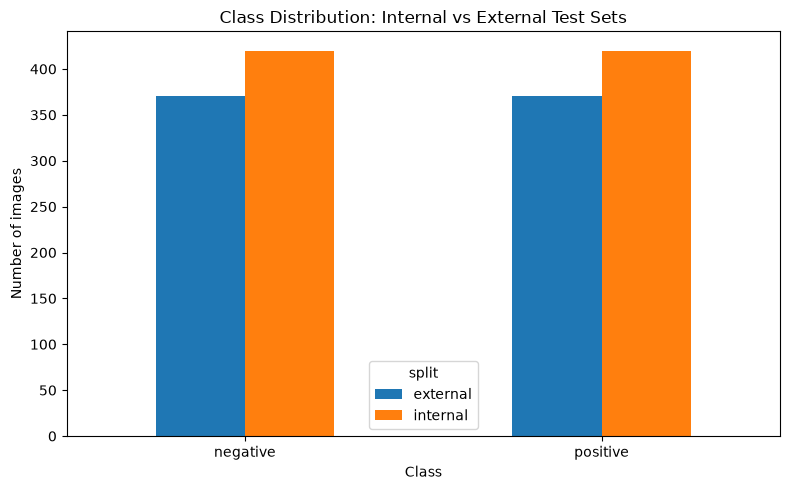

In [6]:
def class_distribution(dataset, split_name):
    counts = Counter(dataset.targets)
    total = len(dataset)

    rows = []
    for class_idx, class_name in enumerate(dataset.classes):
        count = counts.get(class_idx, 0)
        rows.append({
            "split": split_name,
            "class_index": class_idx,
            "class_name": class_name,
            "count": count,
            "proportion": count / total if total else np.nan,
        })

    return pd.DataFrame(rows)


class_balance = pd.concat([
    class_distribution(test_internal_raw, "internal"),
    class_distribution(test_external_raw, "external"),
], ignore_index=True)

display(class_balance)

# Side-by-side count comparison.
pivot_counts = class_balance.pivot(
    index="class_name",
    columns="split",
    values="count"
)

ax = pivot_counts.plot(kind="bar", figsize=(8, 5))
ax.set_title("Class Distribution: Internal vs External Test Sets")
ax.set_xlabel("Class")
ax.set_ylabel("Number of images")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()


### 6.2 Native image dimensions

The model ultimately receives every image resized to `224 × 224`, but the **native dimensions** can still reveal a source-domain difference between studio and mobile data.

At this stage we inspect width, height and aspect ratio only. More targeted image-quality measures such as blur, brightness, contrast, compression artefacts or noise can be added later if the baseline results and visual inspection justify those hypotheses.


In [7]:
def collect_image_metadata(dataset, split_name):
    records = []

    # ImageFolder.samples contains (file_path, class_index).
    for image_path, class_idx in tqdm.tqdm(
        dataset.samples,
        desc=f"Inspecting {split_name} image metadata"
    ):
        with Image.open(image_path) as img:
            width, height = img.size

        records.append({
            "split": split_name,
            "class_index": class_idx,
            "class_name": dataset.classes[class_idx],
            "width": width,
            "height": height,
            "aspect_ratio": width / height if height else np.nan,
            "pixels": width * height,
        })

    return pd.DataFrame(records)


image_metadata = pd.concat([
    collect_image_metadata(test_internal_raw, "internal"),
    collect_image_metadata(test_external_raw, "external"),
], ignore_index=True)

dimension_summary = (
    image_metadata
    .groupby("split")[["width", "height", "aspect_ratio", "pixels"]]
    .agg(["min", "median", "mean", "max"])
    .round(2)
)

display(dimension_summary)


Inspecting external image metadata: 100%|██████████| 740/740 [00:01<00:00, 498.86it/s]


width                    height                    aspect_ratio  \
           min median   mean  max    min median   mean  max          min   
split                                                                      
external   178  178.0  178.0  178    218  218.0  218.0  218         0.82   
internal   178  178.0  178.0  178    218  218.0  218.0  218         0.82   

                            pixels                           
         median  mean   max    min   median     mean    max  
split                                                        
external   0.82  0.82  0.82  38804  38804.0  38804.0  38804  
internal   0.82  0.82  0.82  38804  38804.0  38804.0  38804

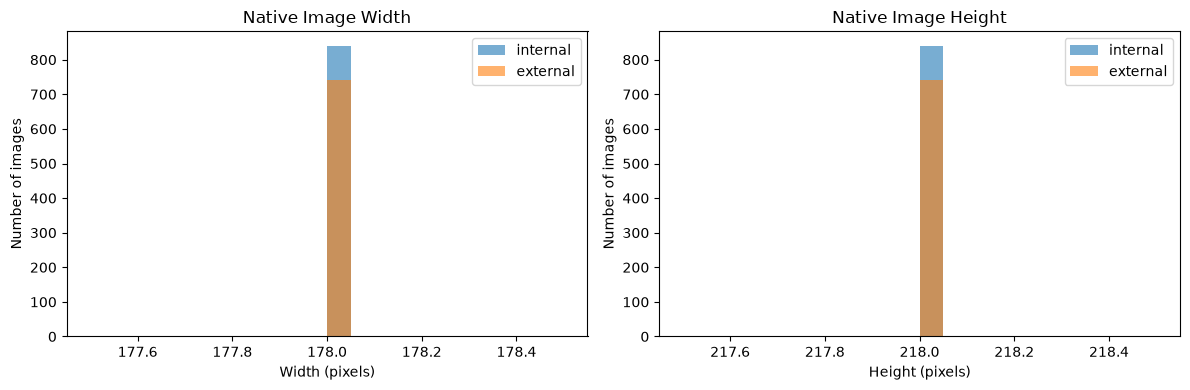

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for split in ["internal", "external"]:
    subset = image_metadata[image_metadata["split"] == split]
    axes[0].hist(subset["width"], bins=20, alpha=0.6, label=split)
    axes[1].hist(subset["height"], bins=20, alpha=0.6, label=split)

axes[0].set_title("Native Image Width")
axes[0].set_xlabel("Width (pixels)")
axes[0].set_ylabel("Number of images")
axes[0].legend()

axes[1].set_title("Native Image Height")
axes[1].set_xlabel("Height (pixels)")
axes[1].set_ylabel("Number of images")
axes[1].legend()

plt.tight_layout()
plt.show()


### 6.3 Representative raw images

The following samples are shown **before resizing and ImageNet normalisation**. Sampling is stratified by class so that both labels are represented in both splits.

When inspecting the images, look for systematic differences between the internal and external domains rather than isolated unusual examples. Relevant observations may include:

- sharpness / blur;
- illumination;
- contrast and colour;
- image noise or compression;
- crop and face scale;
- pose;
- background;
- occlusion;
- any feature that appears correlated with the target class.

Any candidate difference identified here should become a testable hypothesis in the later case-specific investigation.


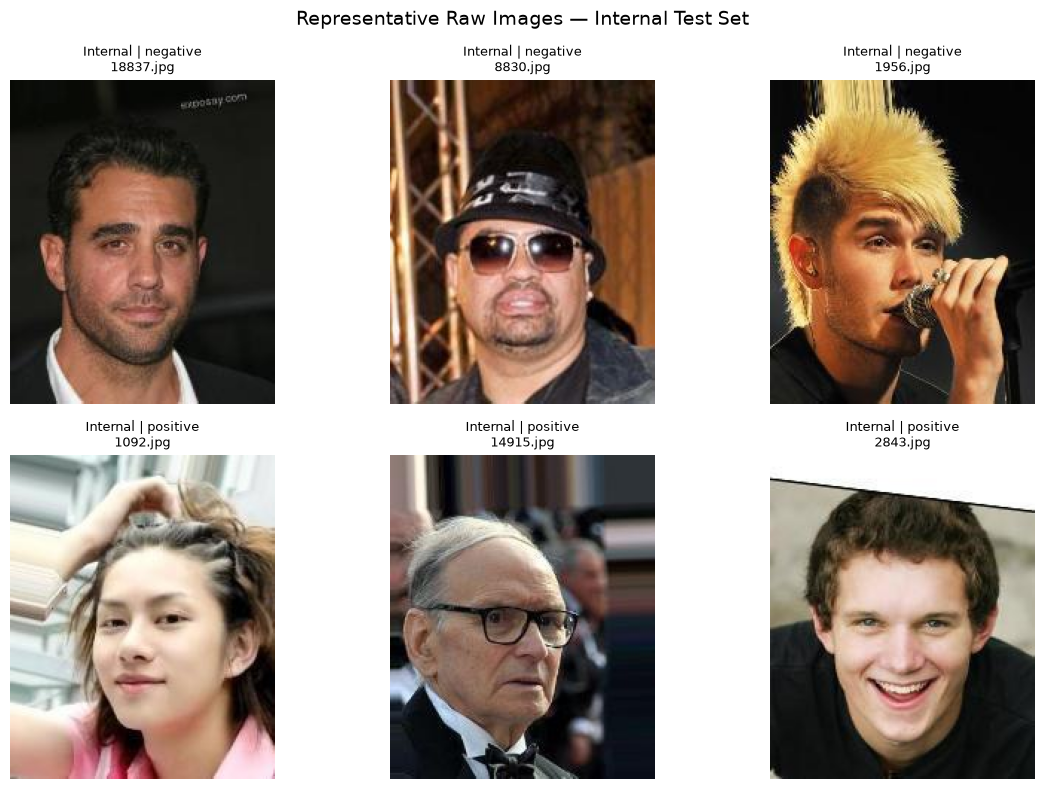

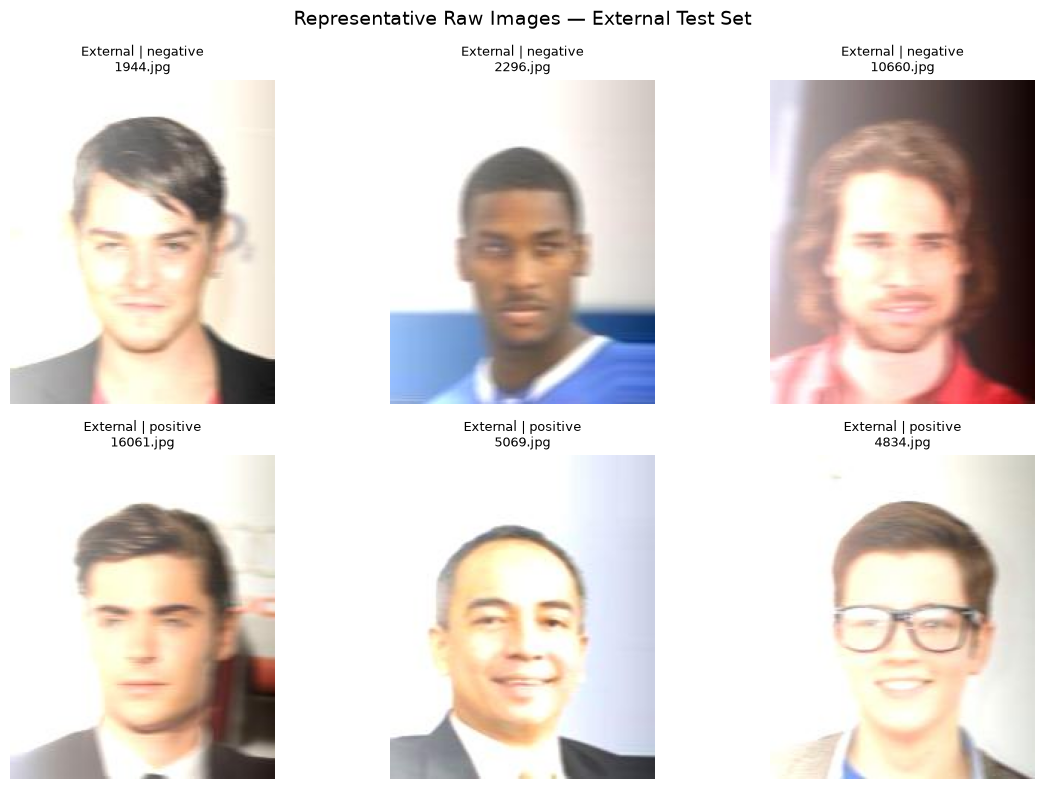

In [9]:
def stratified_sample_paths(dataset, n_per_class=3, seed=SEED):
    rng = random.Random(seed)
    sampled = []

    for class_idx, class_name in enumerate(dataset.classes):
        candidates = [
            path for path, target in dataset.samples
            if target == class_idx
        ]

        n = min(n_per_class, len(candidates))
        for image_path in rng.sample(candidates, n):
            sampled.append((image_path, class_idx, class_name))

    return sampled


def show_representative_samples(dataset, split_name, n_per_class=3, seed=SEED):
    samples = stratified_sample_paths(
        dataset,
        n_per_class=n_per_class,
        seed=seed
    )

    n_classes = len(dataset.classes)
    n_cols = n_per_class
    fig, axes = plt.subplots(
        n_classes,
        n_cols,
        figsize=(4 * n_cols, 4 * n_classes),
        squeeze=False
    )

    for class_idx, class_name in enumerate(dataset.classes):
        class_samples = [s for s in samples if s[1] == class_idx]

        for col in range(n_cols):
            ax = axes[class_idx, col]
            ax.axis("off")

            if col >= len(class_samples):
                continue

            image_path, _, _ = class_samples[col]

            with Image.open(image_path) as img:
                ax.imshow(img.convert("RGB"))

            ax.set_title(
                f"{split_name.title()} | {class_name}\n{Path(image_path).name}",
                fontsize=9
            )

    fig.suptitle(
        f"Representative Raw Images — {split_name.title()} Test Set",
        fontsize=14
    )
    plt.tight_layout()
    plt.show()


show_representative_samples(test_internal_raw, "internal", n_per_class=3)
show_representative_samples(test_external_raw, "external", n_per_class=3)


### 6.4 Initial inspection notes

Complete this interpretation **after running the cells above**.

Record only observations directly supported by the data.

**Class balance**
- Internal:
- External:
- Material difference observed:

**Native image dimensions**
- Internal:
- External:
- Material difference observed:

**Visual comparison**
- Internal / studio characteristics:
- External / mobile characteristics:
- Candidate distribution shifts worth testing:




### Current audit status
At the end of Section 6 we have characterised the two supplied datasets, but we have **not yet diagnosed the model failure**.

The next stage is **Section 7 — Baseline Evaluation**, where the supplied model's predictions will be used to quantify the internal-versus-external performance gap using accuracy and class-sensitive metrics. Those results will determine which candidate shifts from this inspection are worth investigating experimentally.

## 7. Baseline Evaluation

The supplied starter notebook evaluates the model separately on the internal and external test sets using classification accuracy.

For the audit, we retain that baseline but collect a richer set of outputs for every image. This creates a single reproducible prediction table that can support both the baseline evaluation and the later root-cause investigation.

For each image we retain:

- true class;
- predicted class;
- probability assigned to each class;
- model confidence;
- whether the prediction was correct;
- source image path.

The baseline metrics are:

- **Accuracy** — overall proportion of correct predictions;
- **Precision** — how often predicted positives are actually positive;
- **Recall** — how many actual positives are detected;
- **F1-score** — harmonic mean of precision and recall;
- **ROC-AUC** — threshold-independent discrimination between the two classes;
- **Confusion matrix** — counts of the different correct and incorrect prediction types.

The model prediction is obtained with `argmax`, matching the supplied starter notebook.

### 7.1 Collect model predictions

Rather than running separate evaluation code for every later experiment, the following function creates one row per image. Because the data loaders use `shuffle=False`, their iteration order remains aligned with `ImageFolder.samples`.

In [10]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

POSITIVE_CLASS_NAME = "positive"
positive_class_idx = class_to_idx[POSITIVE_CLASS_NAME]


def collect_predictions(model, loader, dataset, split_name, device):
    """Run inference and return one audit record per image."""
    records = []
    sample_offset = 0

    model.eval()

    with torch.inference_mode():
        for images, labels in tqdm.tqdm(
            loader,
            desc=f"Evaluating {split_name}"
        ):
            images = images.to(device)
            labels = labels.to(device)

            logits = model(images)
            probabilities = torch.softmax(logits, dim=1)
            predictions = torch.argmax(probabilities, dim=1)
            confidence = torch.max(probabilities, dim=1).values

            batch_size_actual = labels.shape[0]

            for i in range(batch_size_actual):
                image_path, imagefolder_target = dataset.samples[
                    sample_offset + i
                ]

                true_idx = int(labels[i].item())
                pred_idx = int(predictions[i].item())

                # Sanity check that DataLoader order still matches ImageFolder.samples.
                assert true_idx == imagefolder_target

                records.append({
                    "split": split_name,
                    "image_path": image_path,
                    "true_class_index": true_idx,
                    "true_class": class_names[true_idx],
                    "predicted_class_index": pred_idx,
                    "predicted_class": class_names[pred_idx],
                    "prob_negative": float(
                        probabilities[i, class_to_idx["negative"]].item()
                    ),
                    "prob_positive": float(
                        probabilities[i, positive_class_idx].item()
                    ),
                    "confidence": float(confidence[i].item()),
                    "correct": true_idx == pred_idx,
                })

            sample_offset += batch_size_actual

    return pd.DataFrame(records)


internal_predictions = collect_predictions(
    resnet_frozen,
    test_internal_loader,
    test_internal_dataset,
    "internal",
    device,
)

external_predictions = collect_predictions(
    resnet_frozen,
    test_external_loader,
    test_external_dataset,
    "external",
    device,
)

predictions_df = pd.concat(
    [internal_predictions, external_predictions],
    ignore_index=True
)

print(f"Prediction records collected: {len(predictions_df)}")
display(predictions_df.head())

Evaluating external: 100%|██████████| 47/47 [00:03<00:00, 12.07it/s]

Prediction records collected: 1580


,split,image_path,true_class_index,true_class,predicted_class_index,predicted_class,prob_negative,prob_positive,confidence,correct
0,internal,/home/n10755306/ifn680/IFN680_Sam/Assessment1/...,0,negative,0,negative,0.979373,0.020627,0.979373,True
1,internal,/home/n10755306/ifn680/IFN680_Sam/Assessment1/...,0,negative,0,negative,0.697239,0.302761,0.697239,True
2,internal,/home/n10755306/ifn680/IFN680_Sam/Assessment1/...,0,negative,0,negative,0.999142,0.000858,0.999142,True
3,internal,/home/n10755306/ifn680/IFN680_Sam/Assessment1/...,0,negative,0,negative,0.999257,0.000743,0.999257,True
4,internal,/home/n10755306/ifn680/IFN680_Sam/Assessment1/...,0,negative,0,negative,0.962498,0.037502,0.962498,True


### 7.2 Compute baseline metrics

Precision, recall and F1 use the dataset's `"positive"` class as the positive class. ROC-AUC is calculated from the model's probability assigned to that same class.

These metrics are calculated independently for each split here. The explicit **internal-versus-external performance delta** will be analysed in Section 8.

In [11]:
def calculate_baseline_metrics(predictions, split_name):
    subset = predictions[predictions["split"] == split_name].copy()

    y_true = subset["true_class_index"].to_numpy()
    y_pred = subset["predicted_class_index"].to_numpy()
    y_prob_positive = subset["prob_positive"].to_numpy()

    # Convert the target to a binary indicator for the selected positive class.
    y_true_positive = (y_true == positive_class_idx).astype(int)

    return {
        "split": split_name,
        "n_images": len(subset),
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(
            y_true,
            y_pred,
            pos_label=positive_class_idx,
            zero_division=0,
        ),
        "recall": recall_score(
            y_true,
            y_pred,
            pos_label=positive_class_idx,
            zero_division=0,
        ),
        "f1": f1_score(
            y_true,
            y_pred,
            pos_label=positive_class_idx,
            zero_division=0,
        ),
        "roc_auc": roc_auc_score(
            y_true_positive,
            y_prob_positive,
        ),
    }


baseline_metrics = pd.DataFrame([
    calculate_baseline_metrics(predictions_df, "internal"),
    calculate_baseline_metrics(predictions_df, "external"),
])

display(
    baseline_metrics.style.format({
        "accuracy": "{:.4f}",
        "precision": "{:.4f}",
        "recall": "{:.4f}",
        "f1": "{:.4f}",
        "roc_auc": "{:.4f}",
    })
)

,split,n_images,accuracy,precision,recall,f1,roc_auc
0,internal,840,0.9369,0.9142,0.9643,0.9386,0.9845
1,external,740,0.6189,0.5683,0.9892,0.7219,0.8459


### 7.3 Confusion matrices

The confusion matrices show *how* each split fails, rather than reducing performance to a single score.

Rows represent the **actual class** and columns represent the **predicted class**.

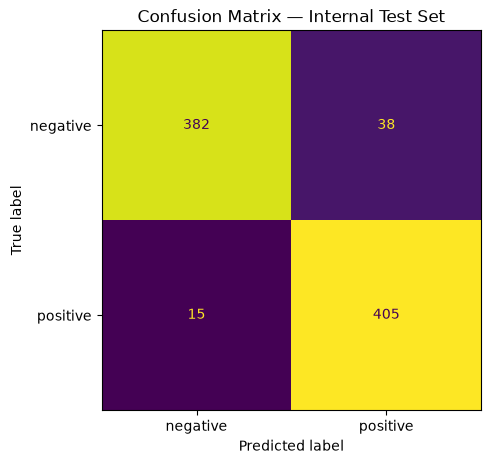

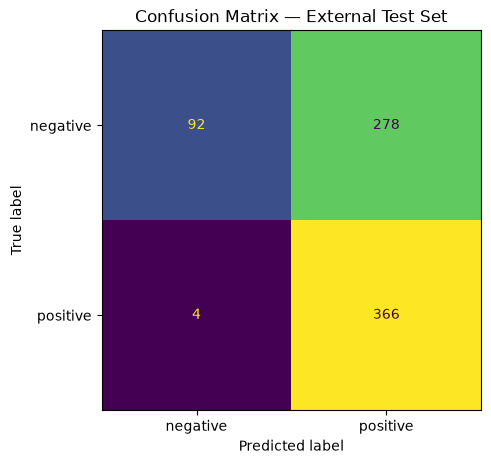

In [12]:
def plot_confusion_matrix_for_split(predictions, split_name):
    subset = predictions[predictions["split"] == split_name]

    y_true = subset["true_class_index"]
    y_pred = subset["predicted_class_index"]

    class_indices = list(range(len(class_names)))

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=class_indices,
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_names,
    )

    fig, ax = plt.subplots(figsize=(5, 5))
    disp.plot(ax=ax, values_format="d", colorbar=False)
    ax.set_title(f"Confusion Matrix — {split_name.title()} Test Set")
    plt.tight_layout()
    plt.show()

    return cm


internal_cm = plot_confusion_matrix_for_split(
    predictions_df,
    "internal"
)

external_cm = plot_confusion_matrix_for_split(
    predictions_df,
    "external"
)

### 7.4 Baseline observations

Complete this section after running the evaluation.

**Internal test set**
- Accuracy:
- Precision:
- Recall:
- F1:
- ROC-AUC:
- Main confusion-matrix observation:

**External test set**
- Accuracy:
- Precision:
- Recall:
- F1:
- ROC-AUC:
- Main confusion-matrix observation:

### Current audit status

Section 7 establishes whether the deployment failure described in the case is reproduced by the supplied test sets and records the model's error pattern.

The next stage is **Section 8 — Internal vs External Comparison**, where the size and nature of the performance degradation will be compared directly. That comparison will then guide the targeted investigation into the specific distribution shift responsible for the failure.

## 8. Internal vs External Comparison

The baseline results establish a clear deployment performance gap. This section compares the two test domains directly to determine **how performance changed**, rather than treating the decrease in accuracy as a single undifferentiated failure.

Three comparisons are especially important:

1. the change in overall performance metrics;
2. the change in class-specific error rates;
3. the change in the model's predicted class distribution.

This distinction matters because a general loss of image quality might produce errors across both classes, whereas the observed confusion matrices suggest a much more directional change in model behaviour.

### 8.1 Performance change between domains

The following table calculates the absolute difference between external and internal performance. For metrics reported on a 0–1 scale, the difference is also shown in **percentage points** for easier interpretation.

In [13]:
# Convert the existing baseline table into one row per metric.
metric_names = ["accuracy", "precision", "recall", "f1", "roc_auc"]

internal_metric_row = (
    baseline_metrics
    .set_index("split")
    .loc["internal", metric_names]
    .astype(float)
)

external_metric_row = (
    baseline_metrics
    .set_index("split")
    .loc["external", metric_names]
    .astype(float)
)

performance_comparison = pd.DataFrame({
    "metric": metric_names,
    "internal": internal_metric_row.values,
    "external": external_metric_row.values,
})

performance_comparison["absolute_change"] = (
    performance_comparison["external"]
    - performance_comparison["internal"]
)

performance_comparison["change_percentage_points"] = (
    performance_comparison["absolute_change"] * 100
)

display(
    performance_comparison.style.format({
        "internal": "{:.4f}",
        "external": "{:.4f}",
        "absolute_change": "{:+.4f}",
        "change_percentage_points": "{:+.2f}",
    })
)

,metric,internal,external,absolute_change,change_percentage_points
0,accuracy,0.9369,0.6189,-0.3180,-31.80
1,precision,0.9142,0.5683,-0.3459,-34.59
2,recall,0.9643,0.9892,+0.0249,+2.49
3,f1,0.9386,0.7219,-0.2167,-21.67
4,roc_auc,0.9845,0.8459,-0.1386,-13.86


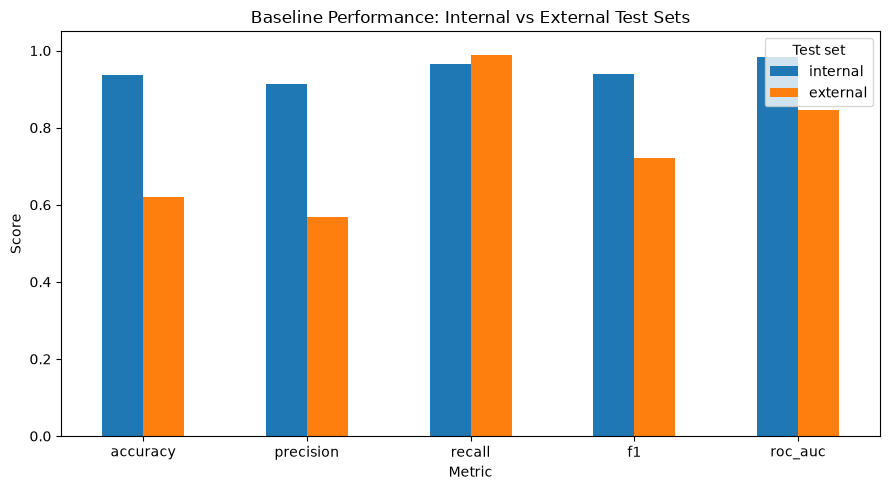

In [14]:
# Visual comparison of the principal baseline metrics.
metric_plot_data = (
    performance_comparison
    .set_index("metric")[["internal", "external"]]
)

ax = metric_plot_data.plot(
    kind="bar",
    figsize=(9, 5),
)

ax.set_title("Baseline Performance: Internal vs External Test Sets")
ax.set_xlabel("Metric")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Test set")

plt.tight_layout()
plt.show()

### 8.2 Class-specific behaviour

Overall accuracy alone hides the most important feature of the deployment failure.

For the positive class:

- **Recall / true-positive rate (TPR)** measures the proportion of actual positive images correctly identified.

For the negative class:

- **Specificity / true-negative rate (TNR)** measures the proportion of actual negative images correctly identified.
- **False-positive rate (FPR)** measures the proportion of actual negative images incorrectly classified as positive.

The false-negative rate (FNR) is also reported for completeness.

These rates let us determine whether the external degradation affects both classes similarly or is concentrated in one direction.

In [15]:
def calculate_class_error_rates(predictions, split_name):
    subset = predictions[predictions["split"] == split_name]

    y_true = subset["true_class_index"].to_numpy()
    y_pred = subset["predicted_class_index"].to_numpy()

    negative_idx = class_to_idx["negative"]
    positive_idx = class_to_idx["positive"]

    tn = np.sum((y_true == negative_idx) & (y_pred == negative_idx))
    fp = np.sum((y_true == negative_idx) & (y_pred == positive_idx))
    fn = np.sum((y_true == positive_idx) & (y_pred == negative_idx))
    tp = np.sum((y_true == positive_idx) & (y_pred == positive_idx))

    tpr = tp / (tp + fn)
    tnr = tn / (tn + fp)
    fpr = fp / (fp + tn)
    fnr = fn / (fn + tp)

    return {
        "split": split_name,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "positive_recall_TPR": tpr,
        "negative_recall_TNR": tnr,
        "false_positive_rate": fpr,
        "false_negative_rate": fnr,
    }


class_error_rates = pd.DataFrame([
    calculate_class_error_rates(predictions_df, "internal"),
    calculate_class_error_rates(predictions_df, "external"),
])

display(
    class_error_rates.style.format({
        "positive_recall_TPR": "{:.4f}",
        "negative_recall_TNR": "{:.4f}",
        "false_positive_rate": "{:.4f}",
        "false_negative_rate": "{:.4f}",
    })
)

,split,TN,FP,FN,TP,positive_recall_TPR,negative_recall_TNR,false_positive_rate,false_negative_rate
0,internal,382,38,15,405,0.9643,0.9095,0.0905,0.0357
1,external,92,278,4,366,0.9892,0.2486,0.7514,0.0108


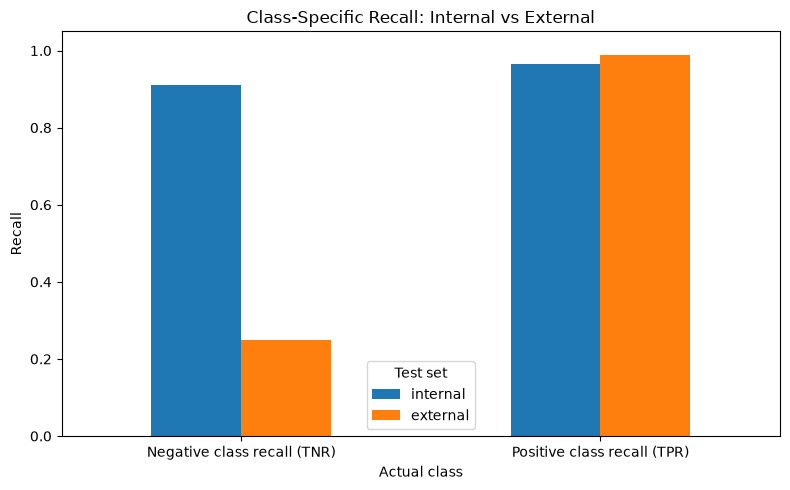

In [16]:
# Plot the two class-specific correct-classification rates.
class_recall_plot = (
    class_error_rates
    .set_index("split")[
        ["negative_recall_TNR", "positive_recall_TPR"]
    ]
    .rename(columns={
        "negative_recall_TNR": "Negative class recall (TNR)",
        "positive_recall_TPR": "Positive class recall (TPR)",
    })
    .T
)

ax = class_recall_plot.plot(
    kind="bar",
    figsize=(8, 5),
)

ax.set_title("Class-Specific Recall: Internal vs External")
ax.set_xlabel("Actual class")
ax.set_ylabel("Recall")
ax.set_ylim(0, 1.05)
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Test set")

plt.tight_layout()
plt.show()

### 8.3 Predicted class distribution

Both test datasets have an identical **50% negative / 50% positive true-label distribution**.

We can therefore compare that known balanced target distribution with the model's output distribution. A large change in the proportion of predicted positives would indicate that the external domain systematically pushes the model toward one side of the decision boundary.

In [17]:
def predicted_class_distribution(predictions):
    rows = []

    for split_name, subset in predictions.groupby("split"):
        total = len(subset)

        for class_name in class_names:
            true_count = int((subset["true_class"] == class_name).sum())
            predicted_count = int(
                (subset["predicted_class"] == class_name).sum()
            )

            rows.append({
                "split": split_name,
                "class_name": class_name,
                "true_count": true_count,
                "true_proportion": true_count / total,
                "predicted_count": predicted_count,
                "predicted_proportion": predicted_count / total,
            })

    return pd.DataFrame(rows)


prediction_distribution = predicted_class_distribution(predictions_df)

display(
    prediction_distribution.style.format({
        "true_proportion": "{:.4f}",
        "predicted_proportion": "{:.4f}",
    })
)

,split,class_name,true_count,true_proportion,predicted_count,predicted_proportion
0,external,negative,370,0.5000,96,0.1297
1,external,positive,370,0.5000,644,0.8703
2,internal,negative,420,0.5000,397,0.4726
3,internal,positive,420,0.5000,443,0.5274


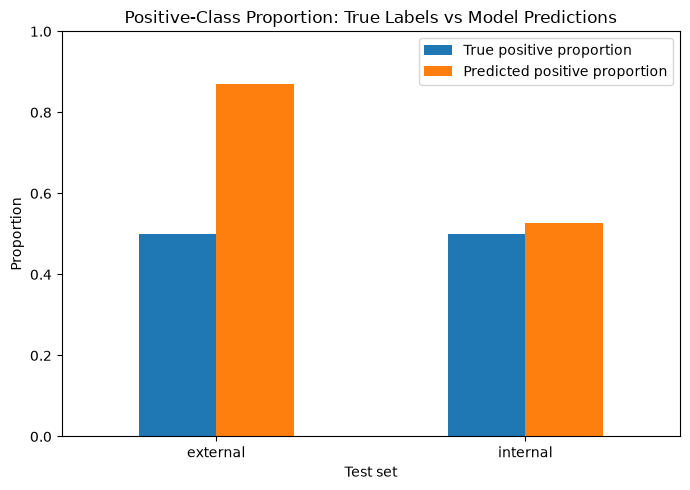

In [18]:
# Compare the proportion of images predicted as positive in each domain.
positive_prediction_rates = (
    prediction_distribution[
        prediction_distribution["class_name"] == "positive"
    ][["split", "true_proportion", "predicted_proportion"]]
    .set_index("split")
)

ax = positive_prediction_rates.plot(
    kind="bar",
    figsize=(7, 5),
)

ax.set_title("Positive-Class Proportion: True Labels vs Model Predictions")
ax.set_xlabel("Test set")
ax.set_ylabel("Proportion")
ax.set_ylim(0, 1.0)
ax.tick_params(axis="x", rotation=0)
ax.legend(["True positive proportion", "Predicted positive proportion"])

plt.tight_layout()
plt.show()

### 8.4 Internal vs external comparison — interpretation

The internal and external datasets are both perfectly class-balanced, but the model's behaviour changes substantially between the two domains.

- Accuracy falls from **93.69% internally to 61.89% externally**, a decrease of approximately **31.80 percentage points**.
- ROC-AUC falls from **0.9845 to 0.8459**, indicating that class discrimination also deteriorates in the external domain.
- The degradation is highly asymmetric across the two classes.
- Positive-class recall remains very high, changing from **96.43% to 98.92%**.
- Negative-class recall falls substantially from **90.95% to 24.86%**.
- Correspondingly, the false-positive rate rises from approximately **9.05% to 75.14%**.
- Although exactly 50% of the external samples are positive, the classifier predicts **644 of 740 external images (87.03%)** as positive.

Therefore, the deployment failure is not simply a general increase in random classification errors. External-domain inputs systematically shift the classifier toward the **positive class**, with most of the lost accuracy caused by negative samples being incorrectly classified as positive.

This establishes the form of the failure, but not yet its root cause. The next investigation examines whether measurable image-quality differences between the internal and external domains can explain this prediction shift.

## 9. Case-Specific Investigation

The baseline audit shows that the external domain strongly shifts predictions toward the positive class. Visual inspection also suggests that external images are generally softer/blurrier and often brighter or lower-contrast than the internal images.

The investigation therefore proceeds in stages:

1. examine how predicted positive probabilities shift between domains;
2. quantify candidate image-quality differences;
3. determine whether these properties are associated with the external false-positive failure;
4. perform controlled perturbation experiments to test whether reproducing the suspected shift causes similar model behaviour.

The aim is to move from an observed correlation to evidence supporting a specific root-cause diagnosis.

### 9.1 Prediction-score shift by true class

The confusion matrices show that external negative samples are responsible for most deployment errors. We therefore inspect the model's predicted probability of the positive class separately for:

- internal negative samples;
- internal positive samples;
- external negative samples;
- external positive samples.

If the external domain is systematically pushing predictions toward the positive class, the largest distribution shift should appear among the **true negative samples**.

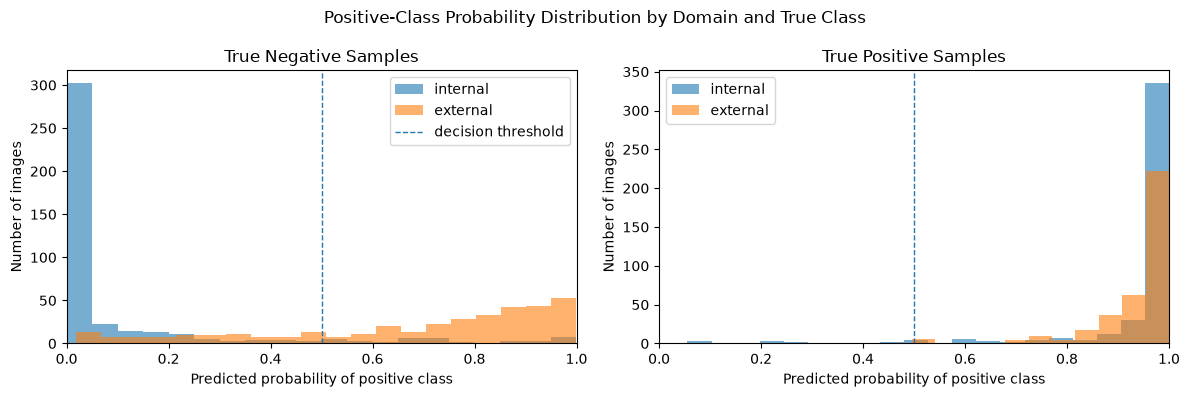

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, true_class in zip(axes, ["negative", "positive"]):
    for split_name in ["internal", "external"]:
        subset = predictions_df[
            (predictions_df["split"] == split_name) &
            (predictions_df["true_class"] == true_class)
        ]

        ax.hist(
            subset["prob_positive"],
            bins=20,
            alpha=0.6,
            label=split_name,
        )

    ax.axvline(
        0.5,
        linestyle="--",
        linewidth=1,
        label="decision threshold" if true_class == "negative" else None,
    )

    ax.set_title(f"True {true_class.title()} Samples")
    ax.set_xlabel("Predicted probability of positive class")
    ax.set_ylabel("Number of images")
    ax.set_xlim(0, 1)
    ax.legend()

plt.suptitle("Positive-Class Probability Distribution by Domain and True Class")
plt.tight_layout()
plt.show()

In [20]:
probability_summary = (
    predictions_df
    .groupby(["split", "true_class"])["prob_positive"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        std="std",
        min="min",
        max="max",
    )
    .round(4)
)

display(probability_summary)

count    mean  median     std     min     max
split    true_class                                               
external negative      370  0.6824  0.7812  0.2784  0.0178  0.9997
         positive      370  0.9330  0.9673  0.1009  0.0829  1.0000
internal negative      420  0.1100  0.0082  0.2262  0.0000  0.9996
         positive      420  0.9410  0.9941  0.1499  0.0557  1.0000

### 9.2 Quantifying candidate image-quality shift

Visual inspection suggests that the external images may differ from the internal images in sharpness and exposure despite having identical dimensions.

Four simple image-level measurements are calculated:

- **Brightness** — mean grayscale intensity;
- **Contrast** — standard deviation of grayscale intensity;
- **Sharpness proxy** — mean magnitude of horizontal and vertical pixel gradients;
- **Bright-pixel proportion** — proportion of grayscale pixels with intensity greater than 245.

All intensity-based measurements are normalised to approximately the range 0–1 where applicable.

These metrics do not themselves establish causation. They are used to determine whether the visually observed differences represent a systematic distribution shift worthy of controlled testing.

In [21]:
def calculate_image_quality_features(image_path):
    with Image.open(image_path) as image:
        grayscale = np.asarray(
            image.convert("L"),
            dtype=np.float32
        ) / 255.0

    # Mean grayscale intensity.
    brightness = grayscale.mean()

    # Standard deviation of intensities.
    contrast = grayscale.std()

    # Simple dependency-free sharpness / edge-strength proxy.
    dx = np.abs(np.diff(grayscale, axis=1)).mean()
    dy = np.abs(np.diff(grayscale, axis=0)).mean()
    sharpness = (dx + dy) / 2

    # Fraction of pixels close to maximum brightness.
    bright_pixel_proportion = (grayscale > (245 / 255)).mean()

    return {
        "brightness": brightness,
        "contrast": contrast,
        "sharpness": sharpness,
        "bright_pixel_proportion": bright_pixel_proportion,
    }


quality_records = []

for _, row in tqdm.tqdm(
    predictions_df.iterrows(),
    total=len(predictions_df),
    desc="Calculating image-quality features"
):
    features = calculate_image_quality_features(row["image_path"])

    quality_records.append({
        "image_path": row["image_path"],
        **features,
    })


quality_df = pd.DataFrame(quality_records)

audit_df = predictions_df.merge(
    quality_df,
    on="image_path",
    how="left",
)

display(audit_df.head())

Calculating image-quality features: 100%|██████████| 1580/1580 [00:04<00:00, 368.87it/s]


,split,image_path,true_class_index,true_class,predicted_class_index,predicted_class,prob_negative,prob_positive,confidence,correct,brightness,contrast,sharpness,bright_pixel_proportion
0,internal,/home/n10755306/ifn680/IFN680_Sam/Assessment1/...,0,negative,0,negative,0.979373,0.020627,0.979373,True,0.525505,0.308739,0.021894,0.021750
1,internal,/home/n10755306/ifn680/IFN680_Sam/Assessment1/...,0,negative,0,negative,0.697239,0.302761,0.697239,True,0.579897,0.240292,0.020909,0.000000
2,internal,/home/n10755306/ifn680/IFN680_Sam/Assessment1/...,0,negative,0,negative,0.999142,0.000858,0.999142,True,0.692098,0.283910,0.027837,0.249897
3,internal,/home/n10755306/ifn680/IFN680_Sam/Assessment1/...,0,negative,0,negative,0.999257,0.000743,0.999257,True,0.399160,0.279142,0.031488,0.042418
4,internal,/home/n10755306/ifn680/IFN680_Sam/Assessment1/...,0,negative,0,negative,0.962498,0.037502,0.962498,True,0.356245,0.287329,0.022061,0.023760


In [22]:
audit_df.head(5)

,split,image_path,true_class_index,true_class,predicted_class_index,predicted_class,prob_negative,prob_positive,confidence,correct,brightness,contrast,sharpness,bright_pixel_proportion
0,internal,/home/n10755306/ifn680/IFN680_Sam/Assessment1/...,0,negative,0,negative,0.979373,0.020627,0.979373,True,0.525505,0.308739,0.021894,0.021750
1,internal,/home/n10755306/ifn680/IFN680_Sam/Assessment1/...,0,negative,0,negative,0.697239,0.302761,0.697239,True,0.579897,0.240292,0.020909,0.000000
2,internal,/home/n10755306/ifn680/IFN680_Sam/Assessment1/...,0,negative,0,negative,0.999142,0.000858,0.999142,True,0.692098,0.283910,0.027837,0.249897
3,internal,/home/n10755306/ifn680/IFN680_Sam/Assessment1/...,0,negative,0,negative,0.999257,0.000743,0.999257,True,0.399160,0.279142,0.031488,0.042418
4,internal,/home/n10755306/ifn680/IFN680_Sam/Assessment1/...,0,negative,0,negative,0.962498,0.037502,0.962498,True,0.356245,0.287329,0.022061,0.023760


#### 9.2.1 Compare internal and external distributions

In [23]:
quality_columns = [
    "brightness",
    "contrast",
    "sharpness",
    "bright_pixel_proportion",
]

quality_summary = (
    audit_df
    .groupby("split")[quality_columns]
    .agg(["mean", "median", "std"])
    .round(4)
)

display(quality_summary)

brightness                 contrast                 sharpness  \
               mean  median     std     mean  median     std      mean   
split                                                                    
external     0.7053  0.7125  0.1181   0.2357  0.2384  0.0474    0.0108   
internal     0.4379  0.4290  0.1460   0.2465  0.2460  0.0508    0.0233   

                         bright_pixel_proportion                  
          median     std                    mean  median     std  
split                                                             
external  0.0105  0.0026                  0.2482  0.2250  0.1679  
internal  0.0223  0.0075                  0.0320  0.0011  0.0875

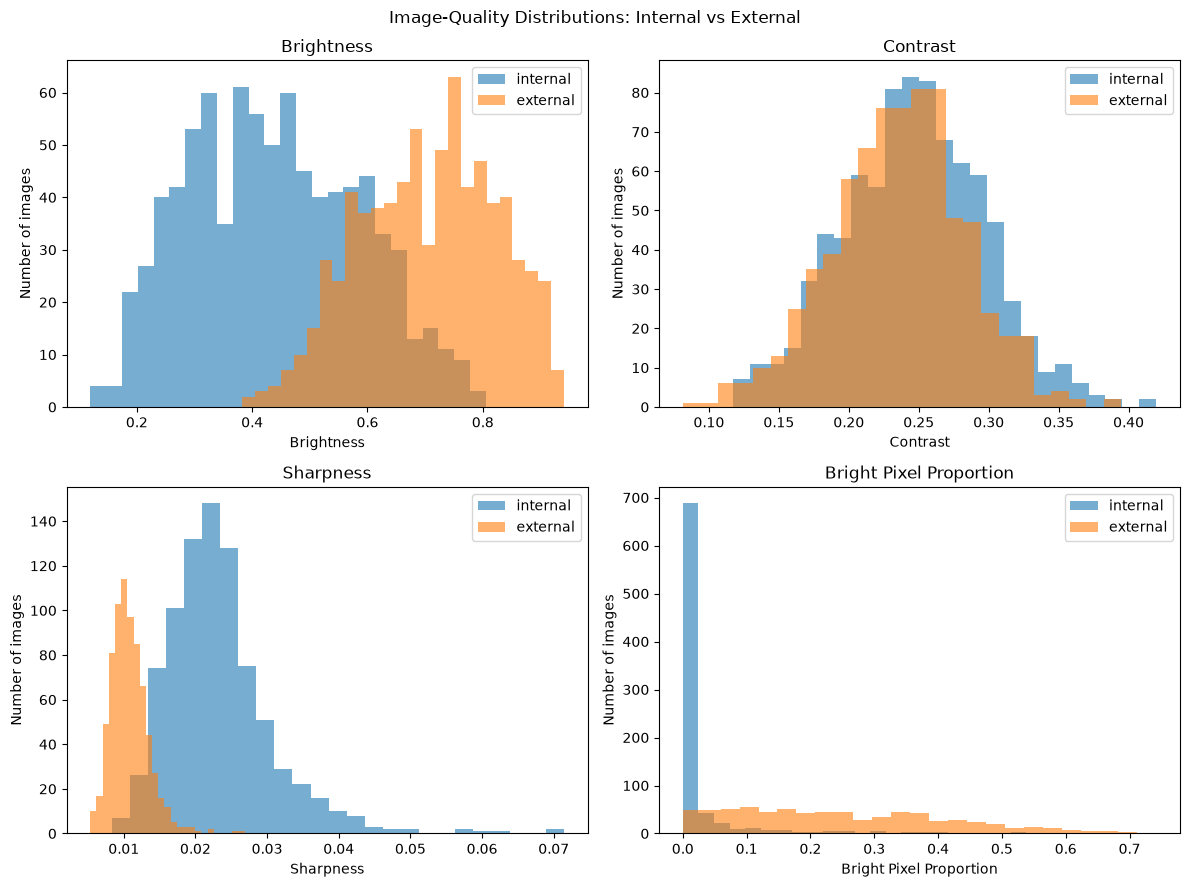

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

for ax, feature in zip(axes.flat, quality_columns):
    for split_name in ["internal", "external"]:
        subset = audit_df[
            audit_df["split"] == split_name
        ]

        ax.hist(
            subset[feature],
            bins=25,
            alpha=0.6,
            label=split_name,
        )

    ax.set_title(feature.replace("_", " ").title())
    ax.set_xlabel(feature.replace("_", " ").title())
    ax.set_ylabel("Number of images")
    ax.legend()

plt.suptitle("Image-Quality Distributions: Internal vs External")
plt.tight_layout()
plt.show()

### 9.3 Image quality and the external false-positive failure

The external performance degradation is dominated by negative images being predicted as positive.

The next comparison therefore focuses only on **true negative samples** and separates them into:

- internal correctly classified negatives;
- external correctly classified negatives;
- external false positives.

If an image-quality characteristic is associated with the deployment failure, the external false-positive group may differ systematically from correctly classified negative samples.

In [25]:
negative_audit = audit_df[
    audit_df["true_class"] == "negative"
].copy()

negative_audit["audit_group"] = np.select(
    [
        (
            (negative_audit["split"] == "internal") &
            (negative_audit["correct"])
        ),
        (
            (negative_audit["split"] == "external") &
            (negative_audit["correct"])
        ),
        (
            (negative_audit["split"] == "external") &
            (~negative_audit["correct"])
        ),
    ],
    [
        "Internal correct negative",
        "External correct negative",
        "External false positive",
    ],
    default="Other",
)

negative_quality_summary = (
    negative_audit[
        negative_audit["audit_group"] != "Other"
    ]
    .groupby("audit_group")[
        [
            "prob_positive",
            "brightness",
            "contrast",
            "sharpness",
            "bright_pixel_proportion",
        ]
    ]
    .agg(["count", "mean", "median", "std"])
    .round(4)
)

display(negative_quality_summary)

prob_positive                         brightness  \
                                  count    mean  median     std      count   
audit_group                                                                  
External correct negative            92  0.2589  0.2611  0.1450         92   
External false positive             278  0.8225  0.8514  0.1308        278   
Internal correct negative           382  0.0458  0.0069  0.0906        382   

                                                  contrast                  \
                             mean  median     std    count    mean  median   
audit_group                                                                  
External correct negative  0.6832  0.6880  0.1297       92  0.2345  0.2326   
External false positive    0.7081  0.7190  0.1186      278  0.2335  0.2351   
Internal correct negative  0.4325  0.4242  0.1458      382  0.2455  0.2438   

                                  sharpness                          \
                              std     count    mean  median     std   
audit_group                                                           
External correct negative  0.0406        92  0.0117  0.0116  0.0026   
External false positive    0.0472       278  0.0107  0.0105  0.0026   
Internal correct negative  0.0537       382  0.0241  0.0233  0.0079   

                          bright_pixel_proportion                          
                                            count    mean  median     std  
audit_group                                                                
External correct negative                      92  0.2268  0.2077  0.1611  
External false positive                       278  0.2533  0.2432  0.1679  
Internal correct negative                     382  0.0338  0.0011  0.0923

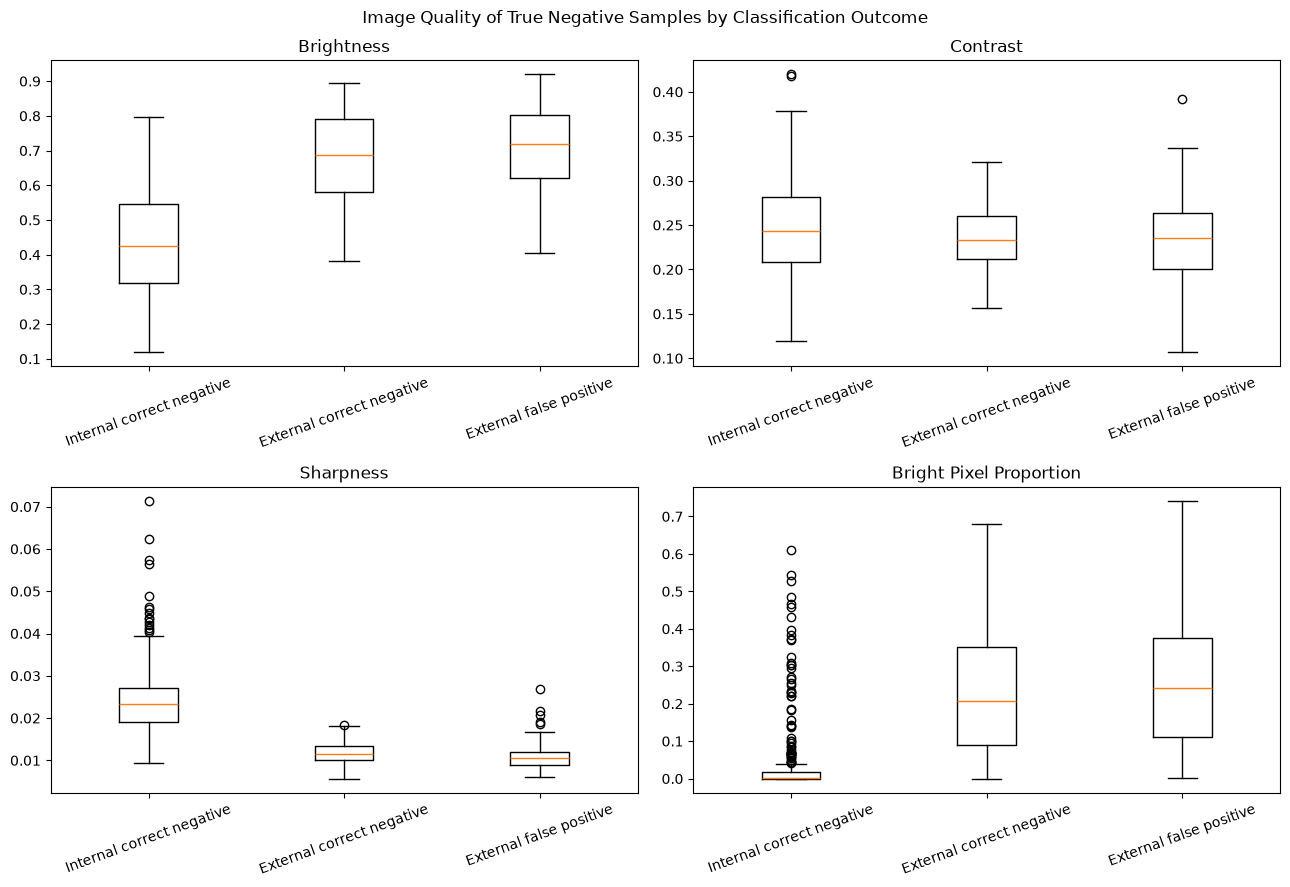

In [26]:
comparison_features = [
    "brightness",
    "contrast",
    "sharpness",
    "bright_pixel_proportion",
]

groups = [
    "Internal correct negative",
    "External correct negative",
    "External false positive",
]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for ax, feature in zip(axes.flat, comparison_features):
    data = [
        negative_audit.loc[
            negative_audit["audit_group"] == group,
            feature
        ].dropna()
        for group in groups
    ]

    ax.boxplot(
        data,
        tick_labels=groups,
    )

    ax.set_title(feature.replace("_", " ").title())
    ax.tick_params(axis="x", rotation=20)

plt.suptitle(
    "Image Quality of True Negative Samples by Classification Outcome"
)
plt.tight_layout()
plt.show()